# 2026 Global and regional hackathon

* For the 2026 hackathon: https://digital-earths-uk-hackathon.github.io/
* This notebook will get you started with the regional, Africa LAM 4.4-km RAL3.3, nested in the N1280 CoMA9 global model.
* There are equivalent LAMs for South Americe (SAmer) and Southeast Asia (SEA)
* There are also LAMS with different physics, using the trailblazer variant of CoMoroph (CoMA9_TBv1).

## Open dataset from catalog

In [1]:
import cartopy.crs as ccrs
import intake
import matplotlib.pyplot as plt

import pandas as pd

import easygems.healpix as egh

from utils import hp_mods, plot_all_fields

In [2]:
# Filter out annoying warning.
import warnings
warnings.filterwarnings("ignore", message=".*The return type of `Dataset.dims` will be changed.*", category=FutureWarning)

In [3]:
# Open catalog.
url = 'https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml'
# cat = intake.open_catalog(url)['UK']
# Use online if not on JASMIN.
cat = intake.open_catalog('https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml')['online']

In [4]:
# Load Africa LAM.
# sim = 'um_Africa_km4p4_RAL3P3_n1280_CoMA9_nest_hk26'
sim = 'um_Africa_km4p4_CoMA9_TBv1_n2560_CoMA9_hier_v2_hk26'
sim_cat = cat[sim]

In [5]:
# Open a 1h (2D) and 3h (3D) dataset.
ds1h = sim_cat(zoom=8, time='PT1H').to_dask().pipe(hp_mods)
ds3h = sim_cat(zoom=8, time='PT3H').to_dask().pipe(hp_mods)

In [6]:
ds1h

<xarray.Dataset> Size: 383GB
Dimensions:  (time: 9745, cell: 393216)
Coordinates:
  * time     (time) datetime64[ns] 78kB 2020-01-20 ... 2021-03-01
  * cell     (cell) int64 3MB 0 1 2 3 4 5 ... 786427 786428 786429 786430 786431
    lat      (cell) float64 3MB 0.1492 0.2984 0.2984 ... -0.2984 -0.2984 -0.1492
    lon      (cell) float64 3MB 45.0 45.18 44.82 45.0 ... 315.2 314.8 315.0
    crs      int64 8B 0
Data variables: (12/26)
    clivi    (time, cell) float32 15GB dask.array<chunksize=(16, 65536), meta=np.ndarray>
    clt      (time, cell) float32 15GB dask.array<chunksize=(16, 65536), meta=np.ndarray>
    hflso    (time, cell) float32 15GB dask.array<chunksize=(16, 65536), meta=np.ndarray>
    hfsso    (time, cell) float32 15GB dask.array<chunksize=(16, 65536), meta=np.ndarray>
    huss     (time, cell) float32 15GB dask.array<chunksize=(16, 65536), meta=np.ndarray>
    pr       (time, cell) float32 15GB dask.array<chunksize=(16, 65536), meta=np.ndarray>
    ...       ...
    rsutcs   (time, cell) float32 15GB dask.array<chunksize=(16, 65536), meta=np.ndarray>
    tas      (time, cell) float32 15GB dask.array<chunksize=(16, 65536), meta=np.ndarray>
    ts       (time, cell) float32 15GB dask.array<chunksize=(16, 65536), meta=np.ndarray>
    uas      (time, cell) float32 15GB dask.array<chunksize=(16, 65536), meta=np.ndarray>
    vas      (time, cell) float32 15GB dask.array<chunksize=(16, 65536), meta=np.ndarray>
    weights  (cell) float32 2MB dask.array<chunksize=(65536,), meta=np.ndarray>
Attributes:
    regional_bounds:       {'lower_left_lat': -40.0, 'lower_left_lon': 340.0,...
    latitiude_convention:  [-90, 90]
    longitude_convention:  [0, 360]
    regional:              True
    simulation:            Africa_km4p4_CoMA9_TBv1.n2560_CoMA9_hier_v2
    processing_version:    v7
    deploy:                prod
    summary:               Met Office DYAMOND3 simulations: A group of experi...
    Conventions:           CF-1.13

## Display data

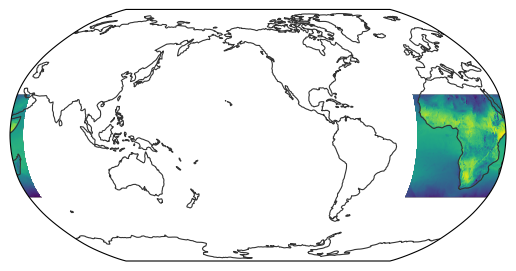

In [7]:
# How can I plot the data?
# What is 'tas'?
egh.healpix_show(ds1h.tas.isel(time=13))

In [8]:
# Let's see all the hourly fields at the second timestamp (00:00 has some variables without data).
# .compute() loads all of the data from the object store into RAM.
ds1h_plot = ds1h.sel(time=pd.Timestamp('2020-01-20 01:00')).compute()

In [19]:
ds1h_plot.tas

<xarray.DataArray 'tas' (cell: 393216)> Size: 2MB
array([299.7651 , 299.68448, 299.78232, ...,       nan,       nan,
             nan], shape=(393216,), dtype=float32)
Coordinates:
  * cell     (cell) int64 3MB 0 1 2 3 4 5 ... 786427 786428 786429 786430 786431
    lat      (cell) float64 3MB 0.1492 0.2984 0.2984 ... -0.2984 -0.2984 -0.1492
    lon      (cell) float64 3MB 45.0 45.18 44.82 45.0 ... 315.2 314.8 315.0
    time     datetime64[ns] 8B 2020-01-20T01:00:00
    crs      int64 8B 0
Attributes:
    standard_name:  air_temperature
    units:          K
    source:         Data from Met Office Unified Model
    um_version:     13.5
    STASH:          [1, 3, 236]
    long_name:      air_temperature
    variable_id:    tas
    UM_vars:        ['air_temperature']
    grid_mapping:   crs

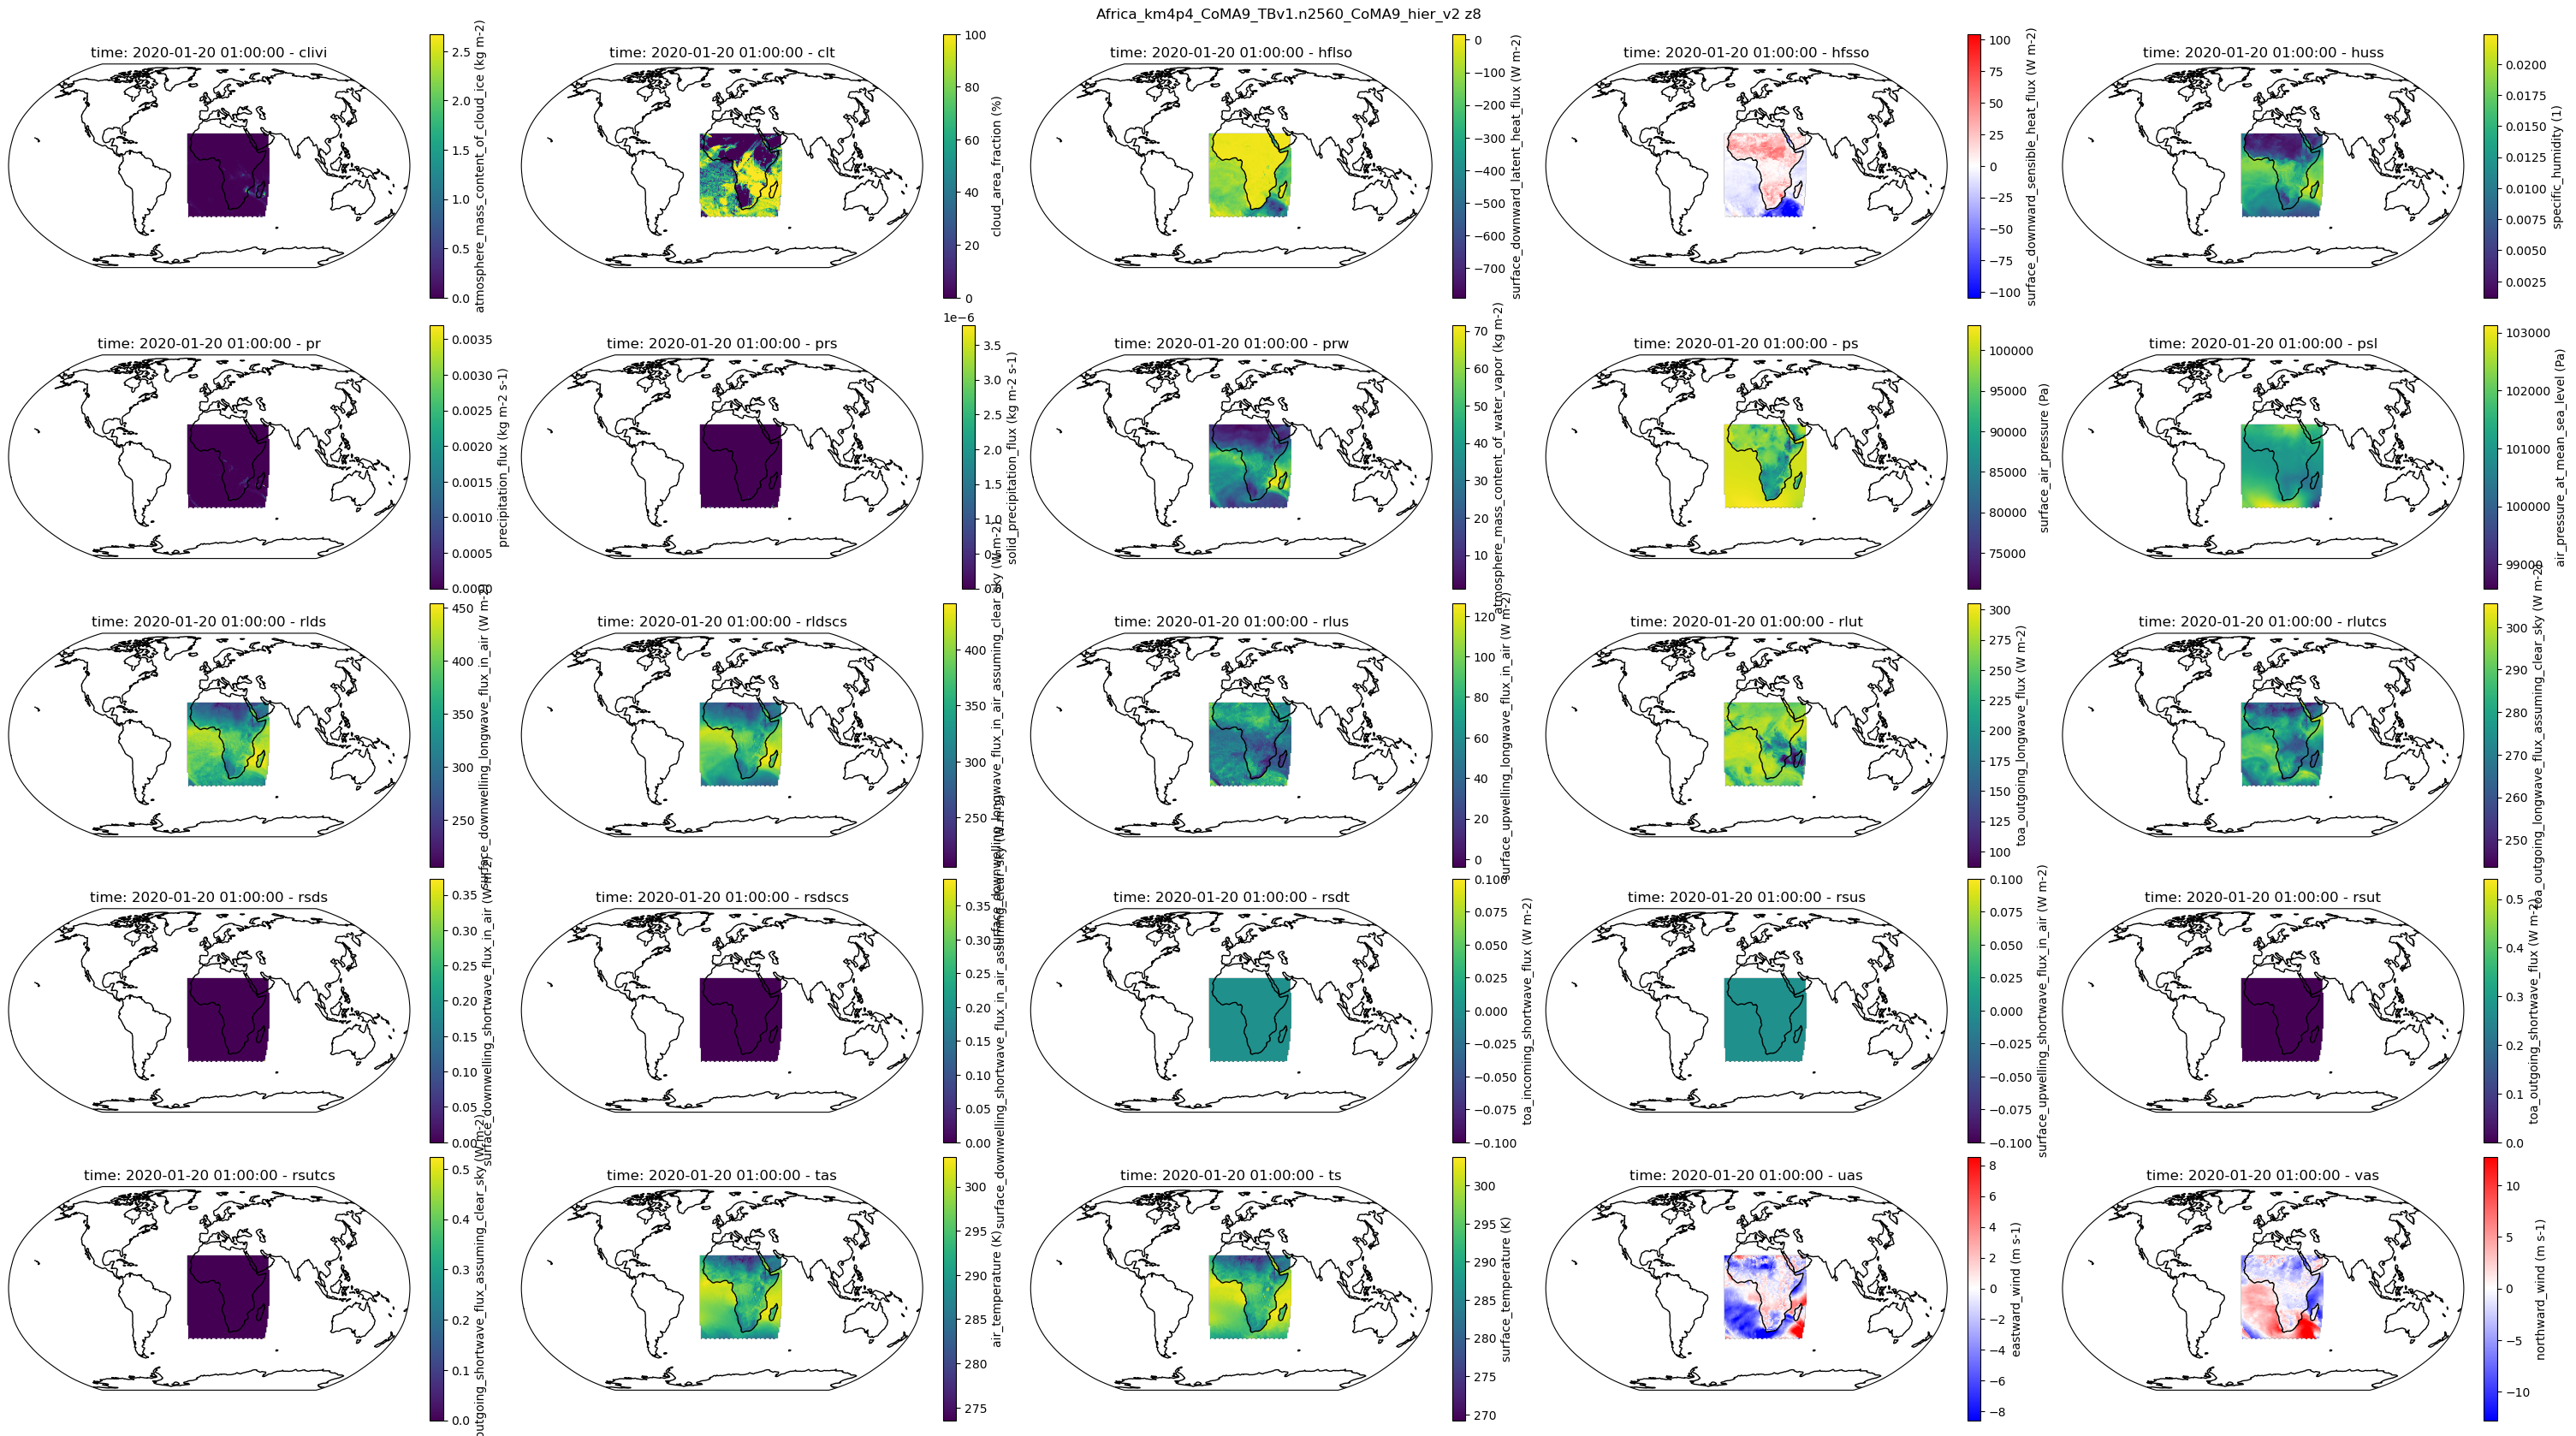

In [10]:
# Plot all fields!
plot_all_fields(ds1h_plot)

In [11]:
# 3-hourly data (3D data) at 900 hPa.
ds3h_plot = ds3h.sel(time=pd.Timestamp('2020-01-20 03:00')).sel(pressure=900).compute()

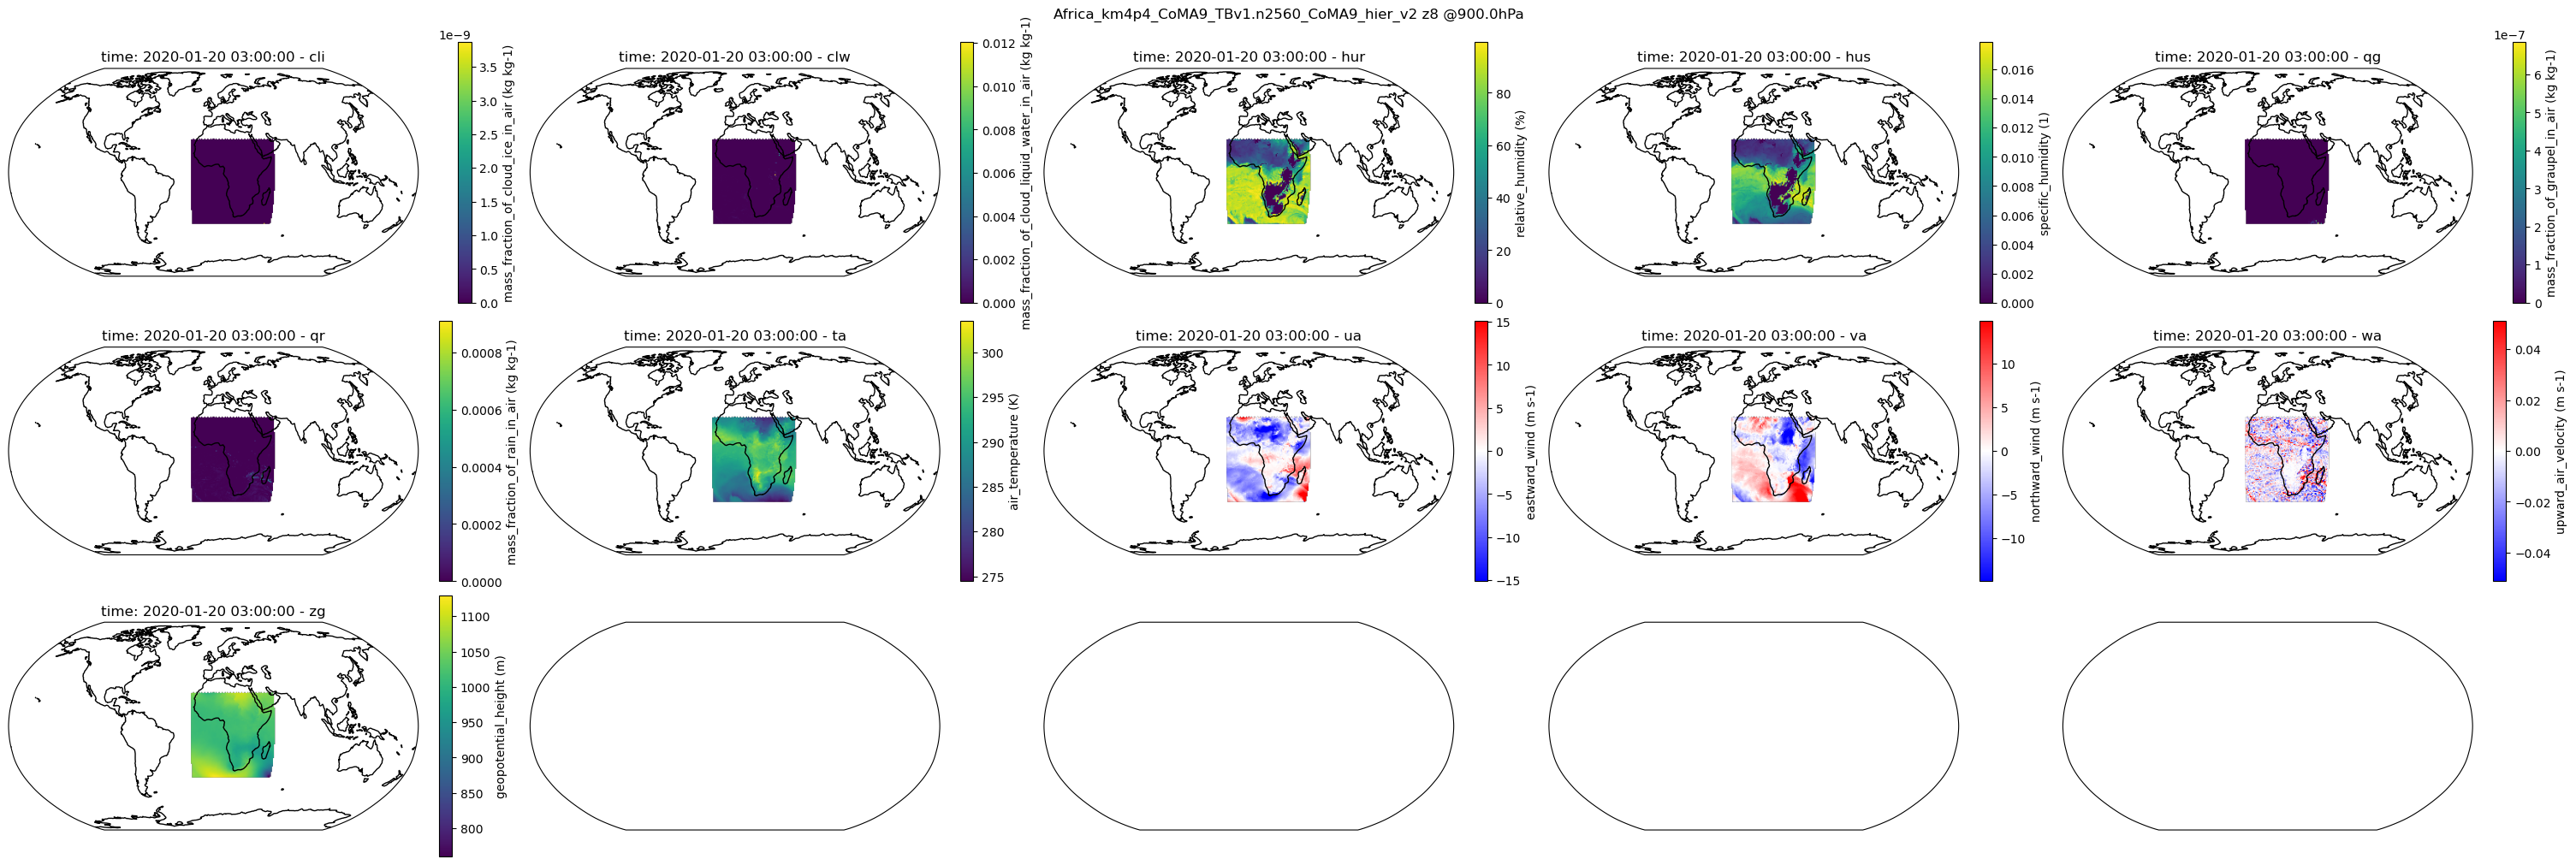

In [12]:
plot_all_fields(ds3h_plot)

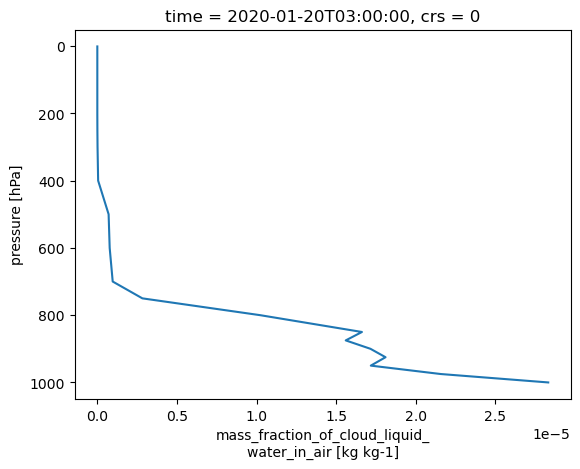

In [13]:
# Check that there's more cloud liquid water in the lower troposphere than stratosphere.
ds3h.isel(time=1).clw.mean(dim='cell').plot(y='pressure', yincrease=False)

## Look at timeseries data

In [20]:
# We can load the data at different zooms. What are the time chunks for zoom 0? Why is this useful?
ds1h_z0 = sim_cat(zoom=8, time='PT1H').to_dask().pipe(hp_mods)
ds1h_z0

<xarray.Dataset> Size: 383GB
Dimensions:  (time: 9745, cell: 393216)
Coordinates:
  * time     (time) datetime64[ns] 78kB 2020-01-20 ... 2021-03-01
  * cell     (cell) int64 3MB 0 1 2 3 4 5 ... 786427 786428 786429 786430 786431
    lat      (cell) float64 3MB 0.1492 0.2984 0.2984 ... -0.2984 -0.2984 -0.1492
    lon      (cell) float64 3MB 45.0 45.18 44.82 45.0 ... 315.2 314.8 315.0
    crs      int64 8B 0
Data variables: (12/26)
    clivi    (time, cell) float32 15GB dask.array<chunksize=(16, 65536), meta=np.ndarray>
    clt      (time, cell) float32 15GB dask.array<chunksize=(16, 65536), meta=np.ndarray>
    hflso    (time, cell) float32 15GB dask.array<chunksize=(16, 65536), meta=np.ndarray>
    hfsso    (time, cell) float32 15GB dask.array<chunksize=(16, 65536), meta=np.ndarray>
    huss     (time, cell) float32 15GB dask.array<chunksize=(16, 65536), meta=np.ndarray>
    pr       (time, cell) float32 15GB dask.array<chunksize=(16, 65536), meta=np.ndarray>
    ...       ...
    rsutcs   (time, cell) float32 15GB dask.array<chunksize=(16, 65536), meta=np.ndarray>
    tas      (time, cell) float32 15GB dask.array<chunksize=(16, 65536), meta=np.ndarray>
    ts       (time, cell) float32 15GB dask.array<chunksize=(16, 65536), meta=np.ndarray>
    uas      (time, cell) float32 15GB dask.array<chunksize=(16, 65536), meta=np.ndarray>
    vas      (time, cell) float32 15GB dask.array<chunksize=(16, 65536), meta=np.ndarray>
    weights  (cell) float32 2MB dask.array<chunksize=(65536,), meta=np.ndarray>
Attributes:
    regional_bounds:       {'lower_left_lat': -40.0, 'lower_left_lon': 340.0,...
    latitiude_convention:  [-90, 90]
    longitude_convention:  [0, 360]
    regional:              True
    simulation:            Africa_km4p4_CoMA9_TBv1.n2560_CoMA9_hier_v2
    processing_version:    v7
    deploy:                prod
    summary:               Met Office DYAMOND3 simulations: A group of experi...
    Conventions:           CF-1.13

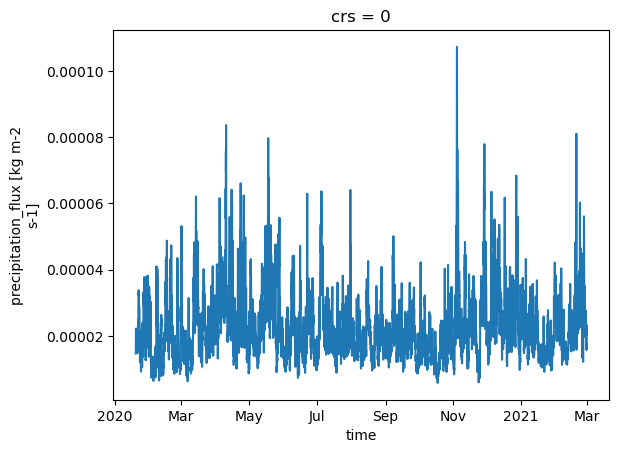

In [15]:
ds1h_z0.pr.mean(dim='cell').plot()